# 02. Replicating the CME FedWatch Tool

The [CME FedWatch tool](https://www.cmegroup.com/markets/interest-rates/cme-fedwatch-tool.html)
publishes the probability of each possible fed funds target range after
upcoming FOMC meetings, backed out of 30-Day Fed Funds futures (ZQ) prices.
It is one of the most-quoted numbers in financial journalism — "markets
price a 58% chance of a hike in September" is FedWatch talking.

This notebook replicates the **simplest case** of the tool: the *next*
scheduled FOMC meeting, with a **binary outcome** — either the Fed leaves
the target range unchanged or it moves once by 25 bps. That single case
contains all of the economic content; the full tool then chains the same
logic across later meetings with a probability tree (out of scope here).

![CME FedWatch target rate probabilities](assets/fedwatch_target_probabilities.png)

*The published FedWatch tool for the September 16, 2026 meeting, captured
August 6, 2026. By the end of this notebook we will have reproduced this
chart from raw futures prices.*

## The methodology

Recall from notebook 01 that a ZQ contract settles at 100 minus the
calendar-day **average** EFFR over its month. Three observations turn that
into meeting probabilities:

**1. A month with no meeting reveals the expected level.** If no FOMC
meeting falls in a month, the rate should be (expected to be) constant
through it, so that month's contract prices the level directly. Using the
month *before* the meeting month as this "anchor":

$$ r_{\text{pre}} = 100 - P_{\text{anchor}}. $$

**2. The meeting month is a day-weighted blend.** Suppose the meeting ends
(the decision is announced) on day $d$ of an $N$-day month; the new rate
takes effect the next day. Then $d$ days accrue at $r_{\text{pre}}$ and
$N - d$ days at the post-meeting rate $r_{\text{post}}$:

$$ r_{\text{avg}} = \frac{d}{N}\, r_{\text{pre}} + \frac{N-d}{N}\, r_{\text{post}}
   \quad\Longrightarrow\quad
   r_{\text{post}} = \frac{r_{\text{avg}}\, N - r_{\text{pre}}\, d}{N - d}. $$

**3. Two possible outcomes identify the probability.** If the only outcomes
are "no change" and one 25 bp move, then
$r_{\text{post}} = r_{\text{pre}} + p \cdot (\pm 0.25)$, so

$$ p_{\text{move}} = \frac{|r_{\text{post}} - r_{\text{pre}}|}{0.25},
   \qquad p_{\text{no change}} = 1 - p_{\text{move}}. $$

**Worked example.** Meeting ends September 16 ($d = 16$, $N = 30$). The
August contract trades at 95.67 ⇒ $r_{\text{pre}} = 4.33\%$; the September
contract at 95.78 ⇒ $r_{\text{avg}} = 4.22\%$. Then
$r_{\text{post}} = (4.22 \times 30 - 4.33 \times 16)/14 \approx 4.09\%$ —
about 24 bps below $r_{\text{pre}}$, so the market prices a **94% chance of
a 25 bp cut**.

**Caveats (documented, not modeled).** This simplest version assumes the
anchor month has no meeting (true for most meetings; the code warns
otherwise — FedWatch anchors to realized EFFR in that case). When a meeting
falls in the last ~3 days of a month, $N - d$ is tiny and the solved
$r_{\text{post}}$ gets noisy, so FedWatch switches to the *next* month's
contract. And moves bigger than 25 bps (like March 2020) violate the binary
assumption. None of these change the core idea.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import fedwatch
import pull_fed_funds_futures

df = pull_fed_funds_futures.load_fed_funds_futures()
meetings = fedwatch.load_fomc_meetings()
meetings.tail()

,meeting_start,meeting_end
11,2026-06-16,2026-06-17
12,2026-07-28,2026-07-29
13,2026-09-15,2026-09-16
14,2026-10-27,2026-10-28
15,2026-12-08,2026-12-09


## Step by step

Find the next meeting after the last date in our data, and identify the
anchor-month and meeting-month contracts.

In [2]:
as_of = df["date"].max()
meeting_end = fedwatch.next_fomc_meeting(meetings, as_of)
meeting_month = pd.Period(meeting_end, freq="M")
anchor_month = meeting_month - 1
print(f"As of {as_of.date()}, the next FOMC decision is {meeting_end.date()}")
print(f"Meeting month: {meeting_month} | anchor month: {anchor_month}")

latest = fedwatch.latest_prices_by_contract(df)
by_month = latest.set_index("contract_month")
by_month.loc[[anchor_month, meeting_month]]

As of 2026-08-05, the next FOMC decision is 2026-09-16
Meeting month: 2026-09 | anchor month: 2026-08


,symbol,date,close
contract_month,,,
2026-08,ZQQ6,2026-08-05,96.3675
2026-09,ZQU6,2026-08-05,96.3000


Translate the two prices into rates and solve for the expected post-meeting
rate.

In [3]:
anchor = by_month.loc[anchor_month]
meeting = by_month.loc[meeting_month]

r_pre = fedwatch.implied_rate(anchor["close"])
r_avg = fedwatch.implied_rate(meeting["close"])

d = meeting_end.day
n = meeting_end.days_in_month
r_post = (r_avg * n - r_pre * d) / (n - d)

print(f"{anchor['symbol']} close {anchor['close']:.4f}  =>  r_pre  = {r_pre:.4f}%")
print(f"{meeting['symbol']} close {meeting['close']:.4f}  =>  r_avg  = {r_avg:.4f}%")
print(
    f"Meeting ends day {d} of {n}  =>  "
    f"r_post = ({r_avg:.4f}*{n} - {r_pre:.4f}*{d}) / {n - d} = {r_post:.4f}%"
)

ZQQ6 close 96.3675  =>  r_pre  = 3.6325%
ZQU6 close 96.3000  =>  r_avg  = 3.7000%
Meeting ends day 16 of 30  =>  r_post = (3.7000*30 - 3.6325*16) / 14 = 3.7771%


The gap between $r_{\text{post}}$ and $r_{\text{pre}}$ identifies the
probability under the binary-outcome assumption. We also infer the current
target range by snapping $r_{\text{pre}}$ to the 25 bp grid (EFFR trades
inside the Fed's range, so this is safe).

In [4]:
probs_info = fedwatch.move_probability(r_pre, r_post)
lower, upper = fedwatch.current_target_range(r_pre)

print(f"Expected change: {(r_post - r_pre) * 100:+.1f} bps => {probs_info['direction']}")
print(f"Current target range (inferred): {fedwatch.range_label(lower)} bps")
print(
    f"P({probs_info['direction']}) = |{r_post:.4f} - {r_pre:.4f}| / 0.25 "
    f"= {probs_info['p_move']:.1%}"
)
print(f"P(no change) = {probs_info['p_no_change']:.1%}")

Expected change: +14.5 bps => hike
Current target range (inferred): 350-375 bps
P(hike) = |3.7771 - 3.6325| / 0.25 = 57.9%
P(no change) = 42.1%


## All at once

`fedwatch.compute_fedwatch_forecast` packages exactly the steps above —
same numbers, one call. This is what the pipeline's chart task uses.

In [5]:
summary, probs = fedwatch.compute_fedwatch_forecast(df, meetings)
probs

,outcome,target_range,probability
0,350-375 (no change),350-375,0.421429
1,375-400 (hike),375-400,0.578571


And the FedWatch-style chart (the pipeline writes this to
`_output/fedwatch_latest_forecast.png` and an interactive HTML version for
the chartbook site):

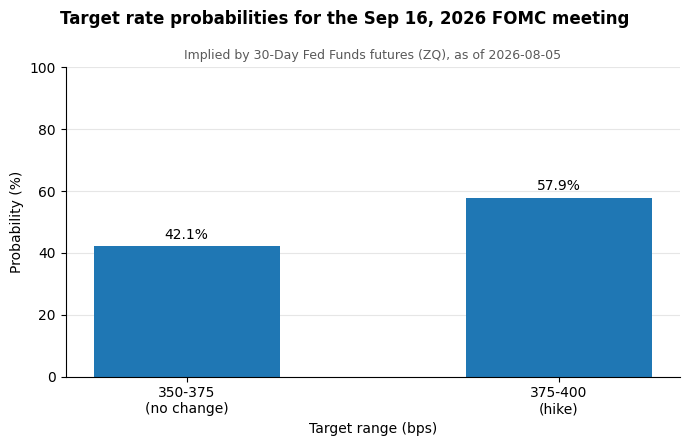

In [6]:
from fedwatch_chart import plot_probabilities_matplotlib

ax = plot_probabilities_matplotlib(summary, probs)
plt.show()

## How close did we get?

Compare the bars above with the FedWatch screenshot at the top of this
notebook, captured when this case study was written (August 6, 2026). For
the September 16, 2026 meeting, FedWatch showed **45.5% no change / 54.5%
hike** from an intraday mid price of 96.2975 on `ZQU6`; our pipeline
computed **42.1% / 57.9%** from the previous day's close of 96.30 —
agreement within about 3.5 percentage points. (If you have refreshed the
data since, the numbers above will have moved with the market.)

That is the expected tolerance, not a bug. The published tool differs from
us in small ways:

- it anchors to **realized EFFR** (and handles anchor months that contain a
  meeting), while we anchor purely to the prior-month futures price;
- it uses official **settlement prices**, while our daily bars' closes can
  differ slightly, and our history lags by a day;
- around month ends it switches which contracts it reads, per the caveats
  above.

**Exercises**

1. Recompute the forecast with `as_of` set to the day before the *last*
   FOMC meeting. Did the market see the decision coming?
2. Plot `p_move` over time for the upcoming meeting by looping
   `compute_fedwatch_forecast` over the as-of dates in the sample. When did
   the market's mind change?
3. The next-but-one meeting's month has a meeting in *its* anchor month
   whenever two meetings fall in adjacent months. Which of our assumptions
   breaks, and how would you fix it using the first meeting's result?